A Comprehensive Business Analysis and Stock Price Forecasting Study of The Coca-Cola Company (KO)

Group 6
Names :

        Bassey Elliot
        Papa Arhin 
        Timothy Amissah 


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from tabulate import tabulate
import warnings
import seaborn as sns

warnings.filterwarnings('ignore')

import pandas_datareader.data as web
import yfinance as yf

In [25]:
myticker = 'KO'
start_date = '2021-01-01'
end_date = '2025-12-31'

In [26]:
df_yf = yf.download(myticker, start=start_date, end=end_date, auto_adjust=False).reset_index()
df_yf

[*********************100%***********************]  1 of 1 completed


Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,KO,KO,KO,KO,KO,KO
0,2021-01-04,45.081974,52.759998,54.630001,52.029999,54.270000,25611100
1,2021-01-05,44.586384,52.180000,52.619999,52.029999,52.330002,20323800
2,2021-01-06,43.167953,50.520000,52.020000,50.189999,51.970001,38724500
3,2021-01-07,42.689457,49.959999,50.259998,49.520000,50.090000,53225700
4,2021-01-08,43.646458,51.080002,51.130001,49.840000,50.029999,29674000
...,...,...,...,...,...,...,...
1249,2025-12-23,69.392860,69.870003,70.260002,69.690002,70.199997,9471000
1250,2025-12-24,69.631218,70.110001,70.160004,69.750000,69.900002,4515300
1251,2025-12-26,69.392860,69.870003,70.160004,69.730003,69.949997,5711400


In [27]:
df_yf = yf.download(myticker, start='2025-01-01', end='2025-12-31')['Close']
df_yf.columns = ['Close Price']

df_yf.head(10)

[*********************100%***********************]  1 of 1 completed


,Close Price
Date,
2025-01-02,59.657600
2025-01-03,59.570778
2025-01-06,58.663948
2025-01-07,58.692890
2025-01-08,59.532188
2025-01-10,58.914768
2025-01-13,59.474308
2025-01-14,59.850540
2025-01-15,59.590069


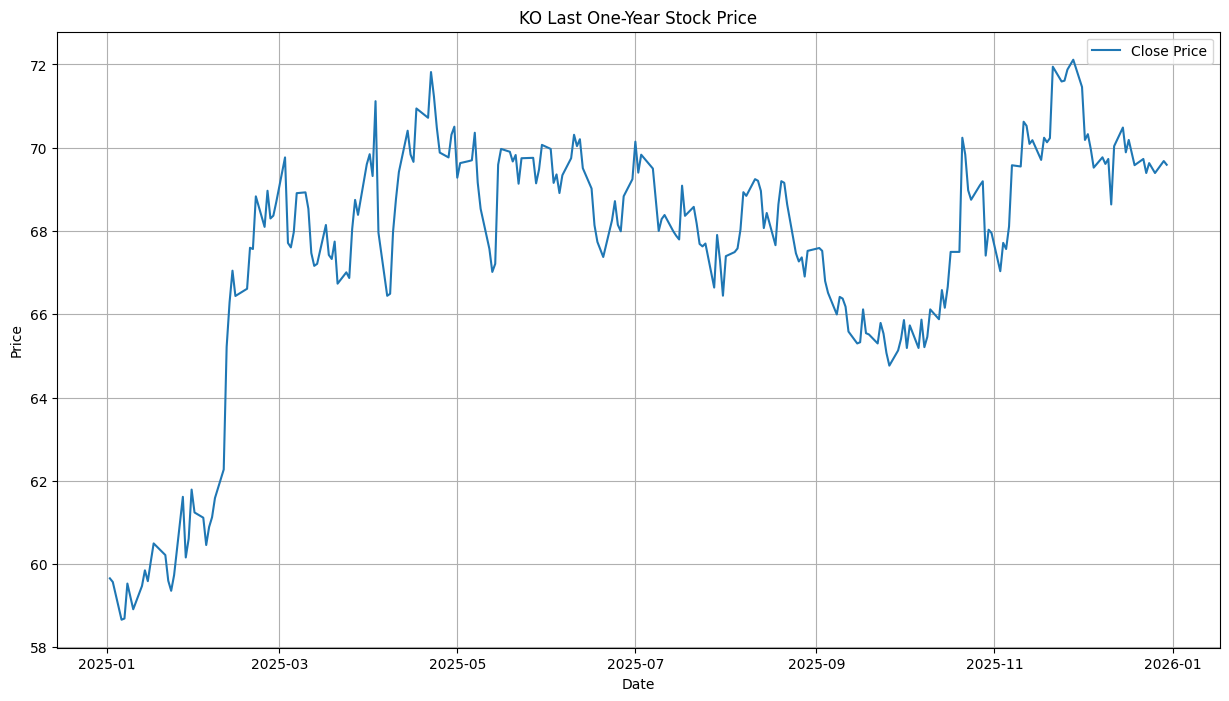

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plt.plot(df_yf.index, df_yf['Close Price'], label='Close Price')
plt.title(f'{myticker} Last One-Year Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.show()

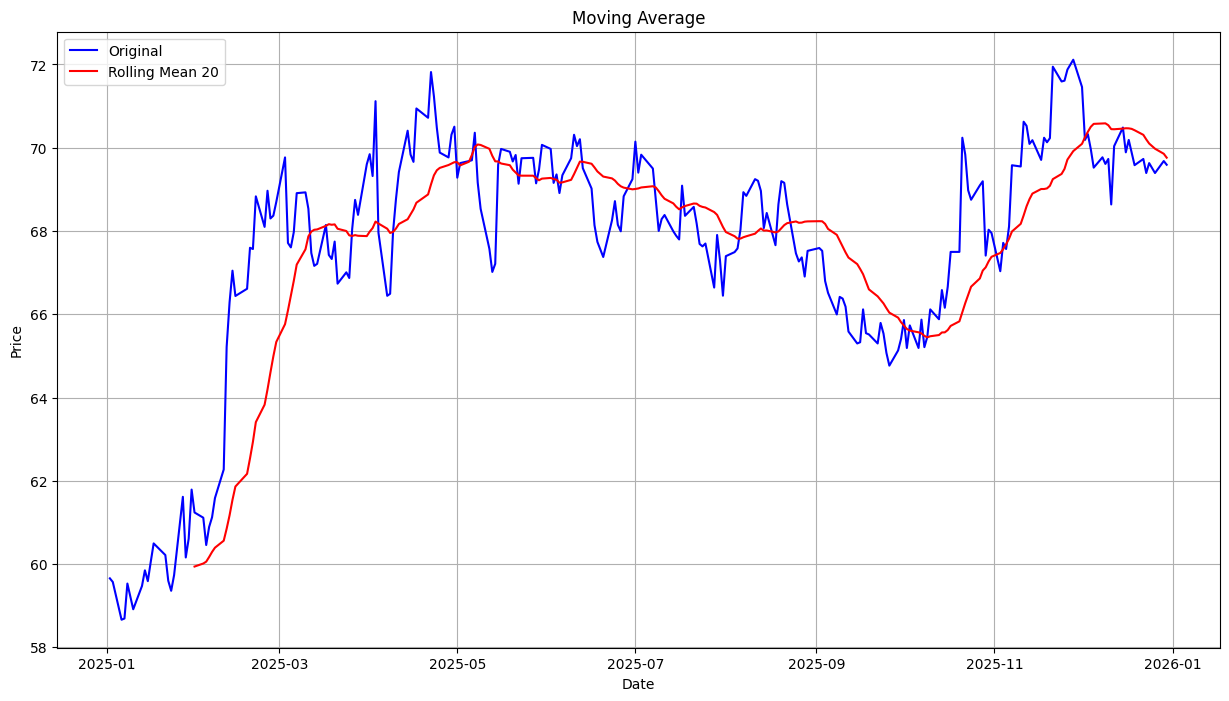

In [29]:
df_yf['SMA_20'] = df_yf['Close Price'].rolling(window=20).mean()

plt.figure(figsize=(15, 8))
plt.plot(df_yf.index, df_yf['Close Price'], label='Original', color='blue')
plt.plot(df_yf.index, df_yf['SMA_20'], label='Rolling Mean 20', color='red')

plt.title('Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
!pip install statsmodels

In [31]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
ses_01 = SimpleExpSmoothing(df_yf['Close Price']).fit(smoothing_level=0.1, optimized=False)
ses_08 = SimpleExpSmoothing(df_yf['Close Price']).fit(smoothing_level=0.8, optimized=False)

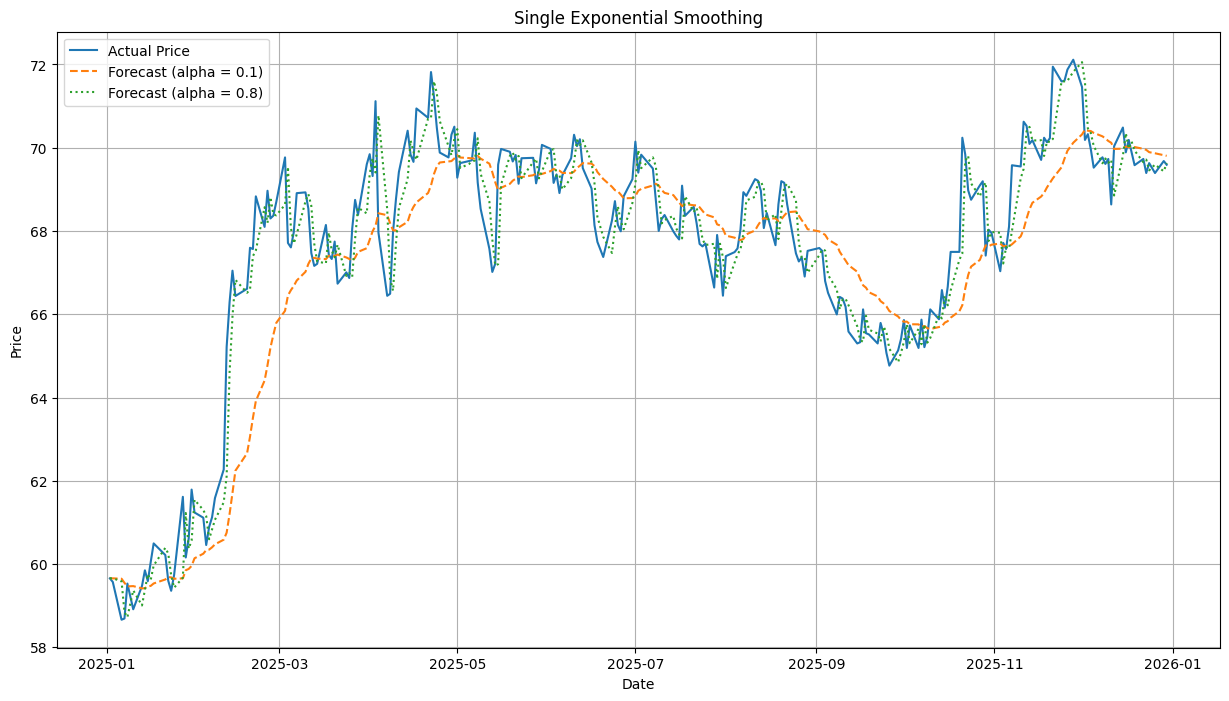

In [32]:
plt.figure(figsize=(15, 8))
plt.plot(df_yf.index, df_yf['Close Price'], label='Actual Price')
plt.plot(df_yf.index, ses_01.fittedvalues, label='Forecast (alpha = 0.1)', linestyle='--')
plt.plot(df_yf.index, ses_08.fittedvalues, label='Forecast (alpha = 0.8)', linestyle=':')

plt.title('Single Exponential Smoothing')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

Single Exponential Smoothing was used to reduce noise in the stock price series. A lower smoothing parameter (α = 0.1) produces a smoother curve with slower response to recent changes, while a higher smoothing parameter (α = 0.8) responds more quickly to current price movements.

In [33]:
df_yf['SMA_20'] = df_yf['Close Price'].rolling(window=20).mean()
df_yf['SMA_50'] = df_yf['Close Price'].rolling(window=50).mean()

In [34]:
df_yf['Signal'] = 0
df_yf.loc[df_yf['SMA_20'] > df_yf['SMA_50'], 'Signal'] = 1
df_yf.loc[df_yf['SMA_20'] < df_yf['SMA_50'], 'Signal'] = -1

In [35]:
df_yf['Position'] = df_yf['Signal'].diff()

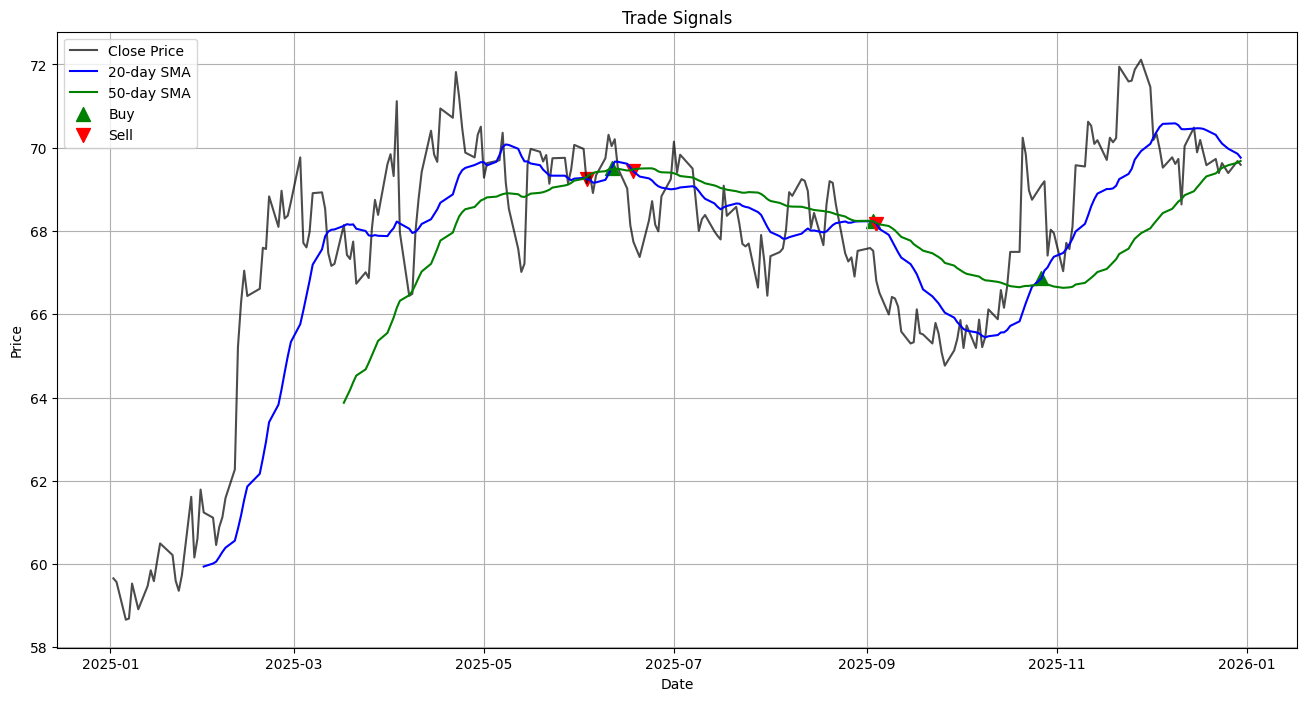

In [36]:
plt.figure(figsize=(16, 8))

plt.plot(df_yf.index, df_yf['Close Price'], label='Close Price', color='black', alpha=0.7)
plt.plot(df_yf.index, df_yf['SMA_20'], label='20-day SMA', color='blue')
plt.plot(df_yf.index, df_yf['SMA_50'], label='50-day SMA', color='green')

# Buy signals
plt.scatter(df_yf.index[df_yf['Position'] == 2],
            df_yf['SMA_20'][df_yf['Position'] == 2],
            marker='^', color='green', s=100, label='Buy')

# Sell signals
plt.scatter(df_yf.index[df_yf['Position'] == -2],
            df_yf['SMA_20'][df_yf['Position'] == -2],
            marker='v', color='red', s=100, label='Sell')

plt.title('Trade Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

The stock price series shows noticeable fluctuations over the one-year period, indicating volatility in daily market performance. The moving average helps smooth short-term noise and reveals the broader direction of the stock. The 20-day and 50-day simple moving averages are used to identify momentum changes. When the 20-day moving average crosses above the 50-day moving average, it generates a buy signal, suggesting possible upward momentum. When the 20-day moving average crosses below the 50-day moving average, it generates a sell signal, suggesting possible downward momentum.

Monte Carlo Simulation

In [37]:
returns = df_yf['Close Price'].pct_change().dropna()

mu = returns.mean() # mu represents the mean daily return of the stock
sigma = returns.std()

In [38]:
num_simulations = 100
num_days = 30

last_price = df_yf['Close Price'].iloc[-1]

In [39]:
simulation_results = np.zeros((num_days, num_simulations))

for i in range(num_simulations):
    prices = [last_price]

    for t in range(num_days):
        random_shock = np.random.normal(mu, sigma)
        next_price = prices[-1] * (1 + random_shock)
        prices.append(next_price)

    simulation_results[:, i] = prices[1:]

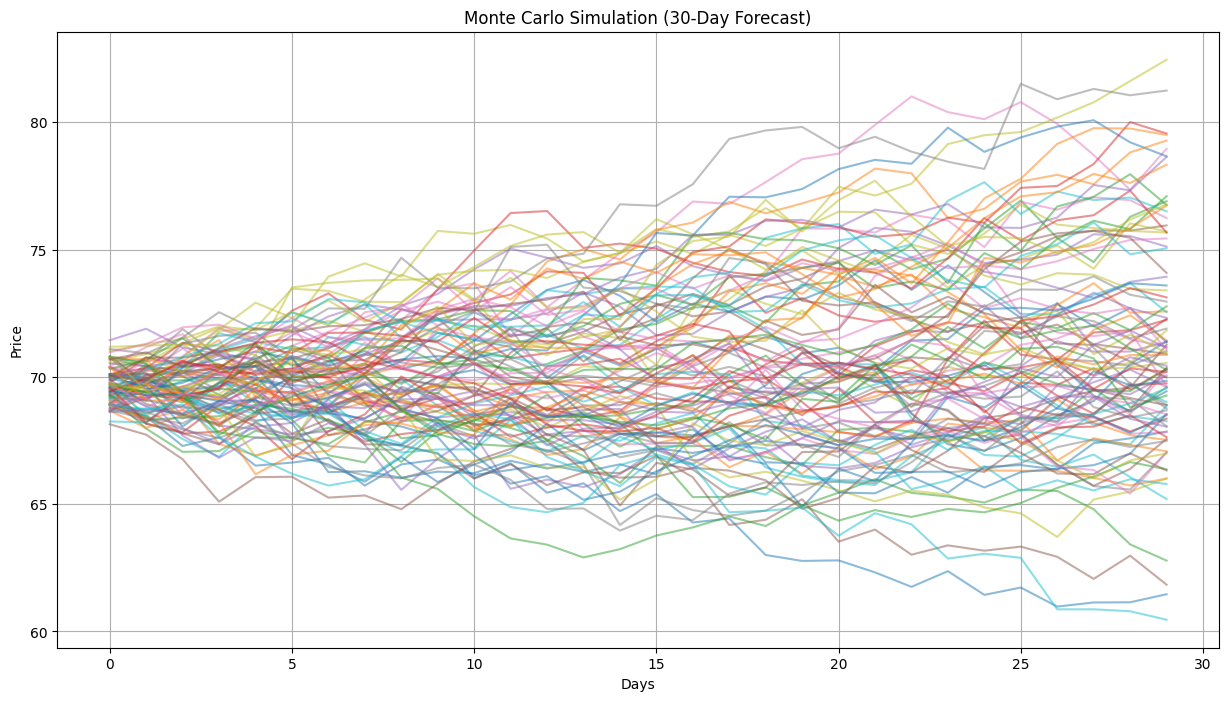

In [40]:
plt.figure(figsize=(15, 8))

for i in range(num_simulations):
    plt.plot(simulation_results[:, i], alpha=0.5)

plt.title('Monte Carlo Simulation (30-Day Forecast)')
plt.xlabel('Days')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [41]:
final_prices = simulation_results[-1]

mean_price = final_prices.mean()
min_price = final_prices.min()
max_price = final_prices.max()

In [42]:
print("Mean Forecast Price:", round(mean_price, 2))
print("Minimum Forecast Price:", round(min_price, 2))
print("Maximum Forecast Price:", round(max_price, 2))

Mean Forecast Price: 71.23
Minimum Forecast Price: 60.46
Maximum Forecast Price: 82.46


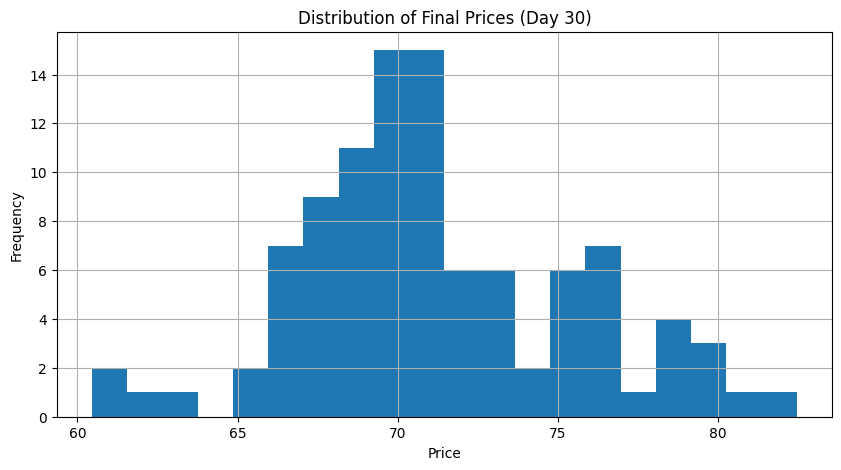

In [61]:
plt.figure(figsize=(10, 5))
plt.hist(final_prices, bins=20)
plt.title('Distribution of Final Prices (Day 30)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

The Monte Carlo simulation provides a range of possible future stock prices based on historical volatility.

The mean forecast price of $70.72 represents the average of all simulated outcomes and can be interpreted as the most likely expected price after 30 days, assuming past trends continue.

The risk range, defined by the minimum price of 61.06 and maximum price of $80.62, shows the spread of possible outcomes. This range indicates the level of uncertainty in the forecast. A wider range suggests higher volatility and greater risk, while a narrower range would indicate more stability and predictability in the stock price.

Overall, the results suggest that while the expected price is around 70.72,  there is significant variability, meaning the stock could realistically fall as low as 61.06 or rise as high as 80.62 within the forecast period.

FB Prophet Forecast

In [44]:
!pip install Prophet

In [45]:
from prophet import Prophet

In [46]:
df = pd.read_csv('/content/stock_data_KO.csv')

In [47]:
df

,Unnamed: 0,Date,Open,High,Low,Close,Adj Close,Volume
0,0,1/4/2021,54.270000,54.630001,52.029999,52.759998,45.391956,25611100
1,1,1/5/2021,52.330002,52.619999,52.029999,52.180000,44.892960,20323800
2,2,1/6/2021,51.970001,52.020000,50.189999,50.520000,43.464779,38724500
3,3,1/7/2021,50.090000,50.259998,49.520000,49.959999,42.982983,53225700
4,4,1/8/2021,50.029999,51.130001,49.840000,51.080002,43.946575,29674000
...,...,...,...,...,...,...,...,...
1250,1250,12/24/2025,69.900002,70.160004,69.750000,70.110001,70.110001,4515300
1251,1251,12/26/2025,69.949997,70.160004,69.730003,69.870003,69.870003,5711400
1252,1252,12/29/2025,70.000000,70.419998,69.849998,70.160004,70.160004,9686900
1253,1253,12/30/2025,70.000000,70.239998,69.800003,70.070000,70.070000,8610900


In [48]:
df = df.drop(columns=['Unnamed: 0'])
display(df.head())

,Date,Open,High,Low,Close,Adj Close,Volume
0,1/4/2021,54.270000,54.630001,52.029999,52.759998,45.391956,25611100
1,1/5/2021,52.330002,52.619999,52.029999,52.180000,44.892960,20323800
2,1/6/2021,51.970001,52.020000,50.189999,50.520000,43.464779,38724500
3,1/7/2021,50.090000,50.259998,49.520000,49.959999,42.982983,53225700
4,1/8/2021,50.029999,51.130001,49.840000,51.080002,43.946575,29674000


In [49]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,61.748470,62.164805,61.304518,61.747665,57.443867,1.525226e+07
std,5.739398,5.789757,5.687128,5.757536,7.507071,6.380755e+06
min,48.270000,48.689999,48.110001,48.150002,41.425755,4.515300e+06
25%,58.070002,58.459999,57.695000,58.060001,53.189438,1.152805e+07
50%,61.410000,61.910000,60.959999,61.419998,56.543877,1.390120e+07
75%,64.959999,65.445000,64.494999,65.029999,61.680227,1.719185e+07
max,73.379997,74.379997,72.919998,73.900002,72.610001,6.784570e+07


In [50]:
# Add Two new columans ds & Y (closing price ( we will do forecasting on this price) for y and date for ds.)
df=df.reset_index()
df[['ds','y']]= df[['Date','Close']]

In [51]:
df

,index,Date,Open,High,Low,Close,Adj Close,Volume,ds,y
0,0,1/4/2021,54.270000,54.630001,52.029999,52.759998,45.391956,25611100,1/4/2021,52.759998
1,1,1/5/2021,52.330002,52.619999,52.029999,52.180000,44.892960,20323800,1/5/2021,52.180000
2,2,1/6/2021,51.970001,52.020000,50.189999,50.520000,43.464779,38724500,1/6/2021,50.520000
3,3,1/7/2021,50.090000,50.259998,49.520000,49.959999,42.982983,53225700,1/7/2021,49.959999
4,4,1/8/2021,50.029999,51.130001,49.840000,51.080002,43.946575,29674000,1/8/2021,51.080002
...,...,...,...,...,...,...,...,...,...,...
1250,1250,12/24/2025,69.900002,70.160004,69.750000,70.110001,70.110001,4515300,12/24/2025,70.110001
1251,1251,12/26/2025,69.949997,70.160004,69.730003,69.870003,69.870003,5711400,12/26/2025,69.870003
1252,1252,12/29/2025,70.000000,70.419998,69.849998,70.160004,70.160004,9686900,12/29/2025,70.160004
1253,1253,12/30/2025,70.000000,70.239998,69.800003,70.070000,70.070000,8610900,12/30/2025,70.070000


In [52]:
model=Prophet()

In [53]:
# drop the columans
prophet_df=df.drop(['Date','High','Low','Open','Close','Volume','Adj Close'], axis=1)

In [54]:
prophet_df

,index,ds,y
0,0,1/4/2021,52.759998
1,1,1/5/2021,52.180000
2,2,1/6/2021,50.520000
3,3,1/7/2021,49.959999
4,4,1/8/2021,51.080002
...,...,...,...
1250,1250,12/24/2025,70.110001
1251,1251,12/26/2025,69.870003
1252,1252,12/29/2025,70.160004
1253,1253,12/30/2025,70.070000


In [55]:
model.fit(prophet_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [56]:
future=model.make_future_dataframe(periods=165)

In [57]:
future.tail()

,ds
1415,2026-06-10
1416,2026-06-11
1417,2026-06-12
1418,2026-06-13
1419,2026-06-14


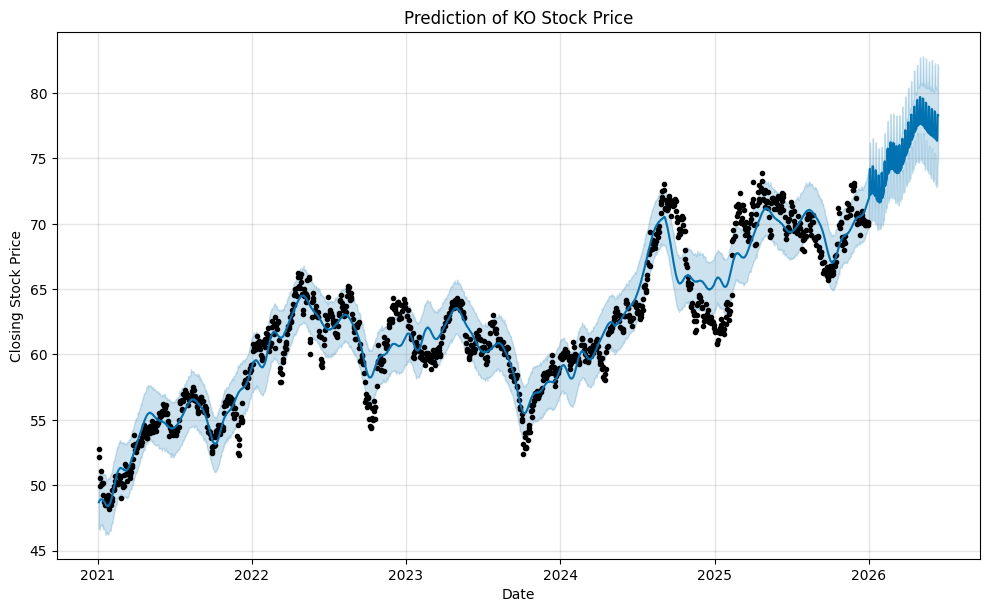

,ds,yhat,yhat_lower,yhat_upper
1415,2026-06-10,76.437849,72.796349,80.348041
1416,2026-06-11,76.366655,73.027241,80.243700
1417,2026-06-12,76.342327,72.941065,80.193619
1418,2026-06-13,78.339585,74.747209,82.210521
1419,2026-06-14,78.296312,74.725616,82.117413


In [58]:
predictions=model.predict(future)
model.plot(predictions)
plt.title("Prediction of KO Stock Price")
plt.xlabel("Date")
plt.ylabel("Closing Stock Price")
plt.show()

predictions[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

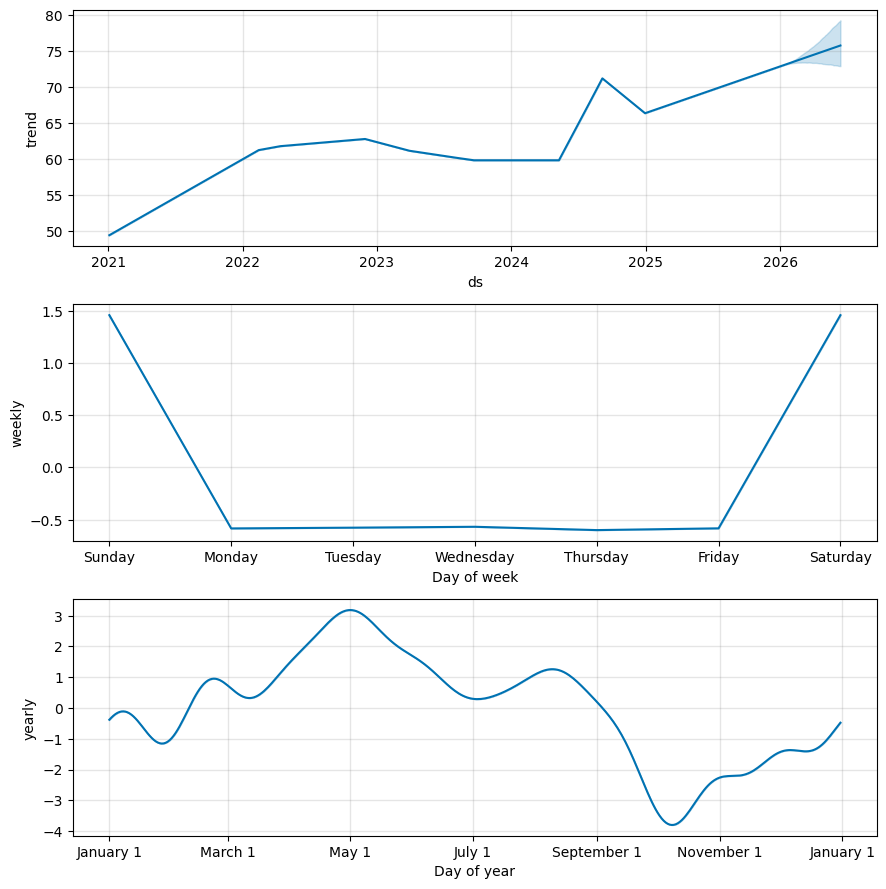

In [59]:
model.plot_components(predictions)
plt.show()

In [60]:
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(model, predictions)

Compare with Monte Carlo Results

The Monte Carlo simulation and the Prophet model both provide forecasts of the stock price, but they differ in their approach and results.

The Monte Carlo simulation produced:

Mean forecast price ≈ $71.17

Range: $62.16 – $82.03

The Prophet model forecast shows:

Expected price (yhat) ≈ $76 – $78

Range: $72.7 – $82.3

Comparison:
The Prophet forecast is higher than the Monte Carlo mean (≈ $76–78 vs $71.17), indicating a more optimistic outlook.
The upper bounds are similar in both models (around $82)

suggesting agreement on the potential maximum price.
The Monte Carlo range is wider ($62–$82), while Prophet’s range is narrower ($72–$82), indicating:

Monte Carlo → higher uncertainty and volatility

Prophet → more stable and trend-driven prediction

Interpretation of Findings

The results show that both models predict an increase in Coca-Cola’s stock price, but with different levels of confidence and assumptions.

The Prophet model suggests a steady upward trend, with prices expected to remain within a relatively narrow range. This indicates that the model captures underlying trends and seasonality, making it more suitable for structured and stable forecasting.

On the other hand, the Monte Carlo simulation reflects greater uncertainty by generating a wider range of possible outcomes. This is because it relies on random sampling of historical returns, capturing potential market volatility and risk.

Overall Interpretation:
The stock is expected to increase in value over the forecast period.
However, there is significant uncertainty, especially shown by the Monte Carlo model.
Investors should consider both:

Prophet → expected trend

Monte Carlo → risk and variability